In [107]:
import refinitiv.data as rd
import pandas as pd
import numpy as np
import warnings
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

rd.open_session()

<refinitiv.data.session.Definition object at 0x169924620 {name='workspace'}>

## 1. Data Fetch

**Data sources:**
- **Refinitiv LSEG:** STOXX Europe 600 index price (`.STOXX`), VSTOXX implied volatility index (`.V2TX`), German 2Y and 10Y government bond mid-yields
- **ECB Data Portal:** Euro area AAA-rated and all-issuer 10Y government bond spot rates (Svensson model)

**Sample period:** 2010-01-01 to 2026-03-05, daily frequency

In [108]:
# --- Refinitiv: equity index and implied volatility ---
# .STOXX  = STOXX Europe 600 price index (daily close)
# .V2TX   = VSTOXX, Euro STOXX 50 implied volatility index (the "European VIX")
df_equity = rd.get_history(
    universe=['.STOXX', '.V2TX'],
    fields=["TRDPRC_1"],
    start="2010-01-01",
    end="2026-03-05",
    interval="daily"
)

# --- Refinitiv: German government bond yields ---
# DE2YT=RR  = German 2-year government bond mid-yield
# DE10YT=RR = German 10-year government bond mid-yield
# These are used to compute the term spread (slope of the yield curve)
df_yields = rd.get_history(
    universe=['DE2YT=RR', 'DE10YT=RR'],
    fields=["MID_YLD_1"],
    start="2010-01-01",
    end="2026-03-05",
    interval="daily"
)

# --- ECB: euro area sovereign yield curves for credit spread proxy ---
# We fetch two ECB yield curve series (10-year spot rates, Svensson model):
#   G_N_A = AAA-rated euro area government bonds (safest issuers: Germany, Netherlands, etc.)
#   G_N_C = All euro area government bonds (includes periphery: Italy, Spain, Greece, etc.)
#
# The spread (all-issuer − AAA) captures the euro area sovereign risk premium.
# This widens during financial stress (e.g. Euro debt crisis 2011-12, COVID 2020)
# and serves as a proxy for credit/systemic risk in the absence of corporate bond data.
ecb_aaa_raw = pd.read_csv(
    "https://data-api.ecb.europa.eu/service/data/YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y"
    "?startPeriod=2010-01-01&endPeriod=2026-03-05&format=csvdata"
)
ecb_all_raw = pd.read_csv(
    "https://data-api.ecb.europa.eu/service/data/YC/B.U2.EUR.4F.G_N_C.SV_C_YM.SR_10Y"
    "?startPeriod=2010-01-01&endPeriod=2026-03-05&format=csvdata"
)

# Parse ECB CSV: keep date (TIME_PERIOD) and yield value (OBS_VALUE)
ecb_aaa = ecb_aaa_raw[['TIME_PERIOD', 'OBS_VALUE']].copy()
ecb_aaa.columns = ['Date', 'aaa_yield']
ecb_aaa['Date'] = pd.to_datetime(ecb_aaa['Date'])
ecb_aaa = ecb_aaa.set_index('Date')

ecb_all = ecb_all_raw[['TIME_PERIOD', 'OBS_VALUE']].copy()
ecb_all.columns = ['Date', 'all_yield']
ecb_all['Date'] = pd.to_datetime(ecb_all['Date'])
ecb_all = ecb_all.set_index('Date')

# Credit spread = all-issuer 10Y yield − AAA 10Y yield (in percentage points)
# Example: if all-issuer = 3.9% and AAA = 3.8%, credit spread = 0.1 pp
df_credit = (ecb_all['all_yield'] - ecb_aaa['aaa_yield']).to_frame(name='credit_spread')

print("Equity shape:", df_equity.shape)
print("Yields shape:", df_yields.shape)
print("Credit shape:", df_credit.shape)
print("\nEquity date range:", df_equity.index.min(), "—", df_equity.index.max())
print("Yields date range:", df_yields.index.min(), "—", df_yields.index.max())
print("Credit date range:", df_credit.index.min(), "—", df_credit.index.max())
print(f"\nCredit spread stats:\n{df_credit.describe()}")

Equity shape: (4153, 2)
Yields shape: (4129, 2)
Credit shape: (4132, 1)

Equity date range: 2010-01-04 00:00:00 — 2026-03-05 00:00:00
Yields date range: 2010-01-04 00:00:00 — 2026-03-05 00:00:00
Credit date range: 2010-01-04 00:00:00 — 2026-03-05 00:00:00

Credit spread stats:
       credit_spread
count    4132.000000
mean        0.710074
std         0.307155
min         0.149098
25%         0.508686
50%         0.644360
75%         0.781656
max         1.948059


## 2. Build HMM Feature Matrix

4 observable features for the HMM:

| Feature | Source | Description |
|---|---|---|
| `stoxx_return` | Refinitiv | Daily log return of STOXX Europe 600 — captures equity market direction |
| `vstoxx` | Refinitiv | VSTOXX level — captures implied volatility / fear in the market |
| `term_spread` | Refinitiv | German 10Y yield − 2Y yield — slope of the yield curve. Positive = normal (expansion expected), flat/negative = inverted (recession signal) |
| `credit_spread` | ECB | All-issuer 10Y yield − AAA 10Y yield — euro area sovereign risk premium. Widens when investors demand more compensation for holding riskier sovereign debt (stress indicator) |

In [109]:
hmm_df = pd.DataFrame(index=df_equity.index)

# Daily log return: ln(P_t / P_{t-1})
stoxx_price = df_equity['.STOXX'].astype(float)
hmm_df['stoxx_return'] = np.log(stoxx_price / stoxx_price.shift(1))

# VSTOXX implied volatility (level, not return — higher = more fear)
hmm_df['vstoxx'] = df_equity['.V2TX'].astype(float)

# Term spread = 10Y yield − 2Y yield (German Bunds)
# Measures the slope of the yield curve:
#   Positive (~1-2%): normal, market expects economic growth
#   Flat/negative:    inverted, historically precedes recessions
hmm_df['term_spread'] = (
    df_yields['DE10YT=RR'].astype(float)
    - df_yields['DE2YT=RR'].astype(float)
)

# Credit spread = all-issuer 10Y − AAA 10Y (ECB sovereign curves)
# Measures the risk premium investors demand for holding average euro area
# sovereign debt vs. the safest (AAA) sovereigns.
# High spread = financial stress (e.g. Euro debt crisis peaked at ~1.95 pp)
# Low spread  = calm markets, risk appetite
hmm_df = hmm_df.join(df_credit, how='left')
# Forward-fill to cover days where ECB data has gaps (e.g. different holiday calendars)
hmm_df['credit_spread'] = hmm_df['credit_spread'].ffill()

features = ['stoxx_return', 'vstoxx', 'term_spread', 'credit_spread']
hmm_df = hmm_df[features].dropna()

print(f"HMM feature matrix: {hmm_df.shape[0]} daily observations")
print(f"Date range: {hmm_df.index.min()} — {hmm_df.index.max()}")
print(f"\nMissing values:\n{hmm_df.isna().sum()}")
print(f"\n{hmm_df.describe()}")

HMM feature matrix: 4114 daily observations
Date range: 2010-01-05 00:00:00 — 2026-03-05 00:00:00

Missing values:
stoxx_return     0
vstoxx           0
term_spread      0
credit_spread    0
dtype: int64

       stoxx_return       vstoxx  term_spread  credit_spread
count   4114.000000  4114.000000  4114.000000    4114.000000
mean       0.000210    21.257330     0.801943       0.709734
std        0.010267     7.293917     0.663325       0.306620
min       -0.121915    10.678300    -0.875500       0.149098
25%       -0.004463    16.382925     0.356125       0.508864
50%        0.000649    19.750750     0.782500       0.644360
75%        0.005598    24.134975     1.339875       0.781447
max        0.080704    85.620600     2.418500       1.948059


## 3. Fit 3-State Gaussian HMM

The HMM assumes the market is always in one of 3 latent (hidden) regimes. At each time step, the 4 observed features are drawn from a multivariate Gaussian distribution whose parameters (mean, covariance) depend on the current hidden state.

- **`n_components=3`**: 3 hidden states (Bull, Bear, Transition)
- **`covariance_type="full"`**: each state has its own full covariance matrix, so the model learns cross-feature correlations per regime (e.g. in Bear states, returns drop while VSTOXX and credit spread rise together)
- **StandardScaler**: features are standardized before fitting because they have very different scales (returns ~0.001, VSTOXX ~20, spreads ~0.7)

In [110]:
# Standardize all features to zero mean, unit variance
# Necessary because HMM emission distributions are scale-sensitive:
# without scaling, VSTOXX (~20) would dominate stoxx_return (~0.001)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hmm_df[features].values)

# Fit 3-state Gaussian HMM with full covariance matrices
model = GaussianHMM(
    n_components=3,          # 3 hidden states
    covariance_type="full",  # full covariance per state (captures correlations)
    n_iter=500,              # max EM iterations
    random_state=42,         # reproducibility
    tol=1e-4                 # convergence threshold for log-likelihood
)
model.fit(X_scaled)

# Viterbi algorithm: find the most likely sequence of hidden states
hmm_df['raw_state'] = model.predict(X_scaled)

print(f"Model converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(X_scaled):.2f}")
print(f"\nState distribution:\n{hmm_df['raw_state'].value_counts().sort_index()}")
print(f"\nTransition matrix (rows = from, cols = to):\n{np.round(model.transmat_, 3)}")

Model converged: True
Log-likelihood: -15569.52

State distribution:
raw_state
0    1070
1    1601
2    1443
Name: count, dtype: int64

Transition matrix (rows = from, cols = to):
[[0.999 0.    0.001]
 [0.    0.994 0.006]
 [0.    0.008 0.992]]


## 4. Label Regimes

HMM states are arbitrary (0, 1, 2) — they have no inherent meaning. We assign economic labels by sorting states by their mean daily STOXX return:
- **Highest mean return → Bull (0):** positive equity returns, low volatility, low spreads
- **Lowest mean return → Bear (1):** negative/flat returns, high volatility, wide spreads
- **Middle → Transition (2):** mixed signals, market shifting between regimes

In [111]:
# Compute mean STOXX return per raw HMM state to determine which is Bull/Bear/Transition
state_means = hmm_df.groupby('raw_state')['stoxx_return'].mean().sort_values(ascending=False)
print("Mean daily STOXX return per raw state:")
print(state_means)

# Map raw states to economic labels based on mean return ranking
sorted_states = state_means.index.tolist()
regime_map = {
    sorted_states[0]: 0,  # highest return → Bull
    sorted_states[2]: 1,  # lowest return  → Bear
    sorted_states[1]: 2,  # middle return  → Transition
}
regime_labels = {0: 'Bull', 1: 'Bear', 2: 'Transition'}

hmm_df['HMM_Regime'] = hmm_df['raw_state'].map(regime_map)

# Sanity check: Bull should have high returns + low VSTOXX, Bear the opposite
print(f"\nRegime mapping (raw_state → regime): {regime_map}")
print(f"\nRegime distribution:")
for regime_id, label in regime_labels.items():
    count = (hmm_df['HMM_Regime'] == regime_id).sum()
    pct = count / len(hmm_df) * 100
    mean_ret = hmm_df.loc[hmm_df['HMM_Regime'] == regime_id, 'stoxx_return'].mean()
    mean_vol = hmm_df.loc[hmm_df['HMM_Regime'] == regime_id, 'vstoxx'].mean()
    mean_cs = hmm_df.loc[hmm_df['HMM_Regime'] == regime_id, 'credit_spread'].mean()
    print(f"  {label} ({regime_id}): {count} days ({pct:.1f}%), "
          f"mean return={mean_ret:.5f}, mean VSTOXX={mean_vol:.1f}, mean credit spread={mean_cs:.3f}")

Mean daily STOXX return per raw state:
raw_state
2    0.000451
0    0.000221
1   -0.000015
Name: stoxx_return, dtype: float64

Regime mapping (raw_state → regime): {2: 0, 1: 1, 0: 2}

Regime distribution:
  Bull (0): 1443 days (35.1%), mean return=0.00045, mean VSTOXX=15.9, mean credit spread=0.655
  Bear (1): 1601 days (38.9%), mean return=-0.00001, mean VSTOXX=23.8, mean credit spread=0.539
  Transition (2): 1070 days (26.0%), mean return=0.00022, mean VSTOXX=24.7, mean credit spread=1.039


## 5. Visualization

Each panel shows one variable over time, colored by HMM regime:
- **Green** = Bull, **Red** = Bear, **Orange** = Transition

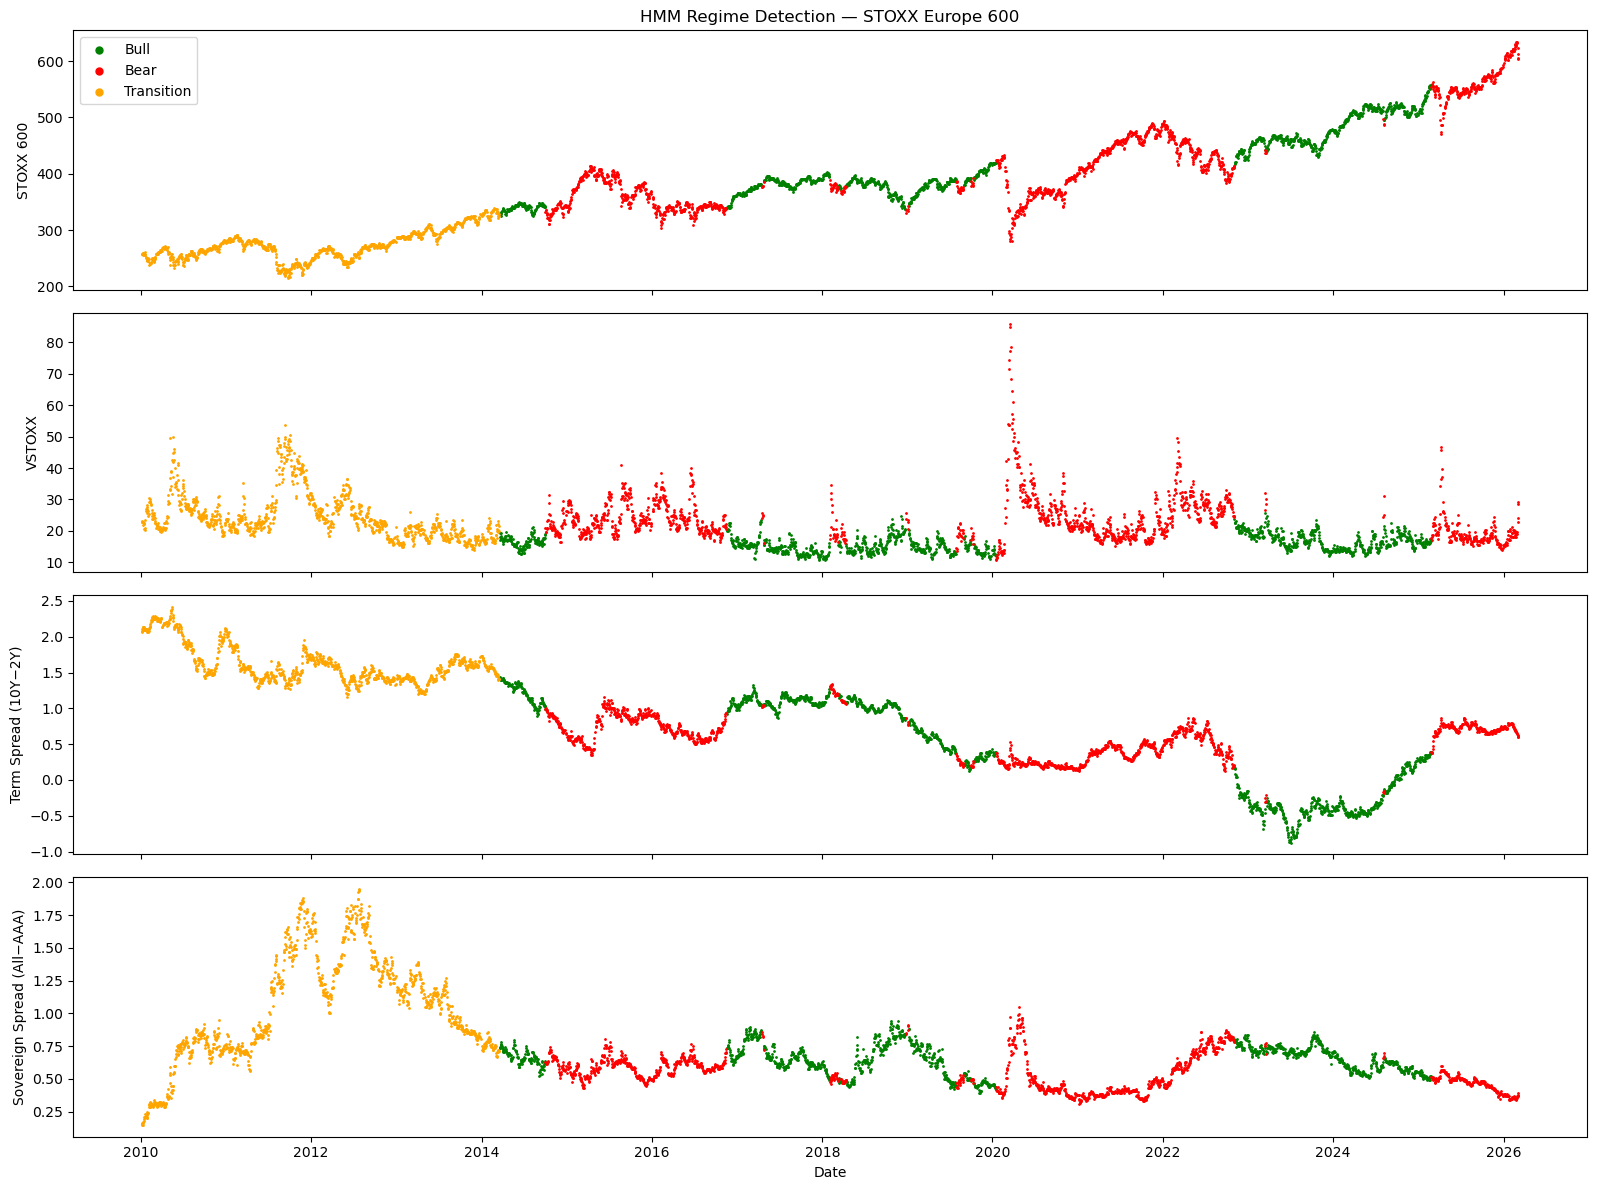

In [112]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

colors = {0: 'green', 1: 'red', 2: 'orange'}
labels = {0: 'Bull', 1: 'Bear', 2: 'Transition'}

# Plot 1: STOXX 600 price with regime coloring
ax1 = axes[0]
stoxx_plot = stoxx_price.reindex(hmm_df.index)
for regime_id, color in colors.items():
    mask = hmm_df['HMM_Regime'] == regime_id
    ax1.scatter(hmm_df.index[mask], stoxx_plot[mask], c=color, s=1, label=labels[regime_id])
ax1.set_ylabel('STOXX 600')
ax1.legend(loc='upper left', markerscale=5)
ax1.set_title('HMM Regime Detection — STOXX Europe 600')

# Plot 2: VSTOXX with regime coloring
ax2 = axes[1]
for regime_id, color in colors.items():
    mask = hmm_df['HMM_Regime'] == regime_id
    ax2.scatter(hmm_df.index[mask], hmm_df.loc[mask, 'vstoxx'], c=color, s=1)
ax2.set_ylabel('VSTOXX')

# Plot 3: Term spread with regime coloring
ax3 = axes[2]
for regime_id, color in colors.items():
    mask = hmm_df['HMM_Regime'] == regime_id
    ax3.scatter(hmm_df.index[mask], hmm_df.loc[mask, 'term_spread'], c=color, s=1)
ax3.set_ylabel('Term Spread (10Y−2Y)')

# Plot 4: Credit spread with regime coloring
ax4 = axes[3]
for regime_id, color in colors.items():
    mask = hmm_df['HMM_Regime'] == regime_id
    ax4.scatter(hmm_df.index[mask], hmm_df.loc[mask, 'credit_spread'], c=color, s=1)
ax4.set_ylabel('Sovereign Spread (All−AAA)')
ax4.set_xlabel('Date')

plt.tight_layout()
plt.show()

## 6. Aggregate to Monthly & Save

The ML models in Stage 3 operate at monthly frequency. We take the regime label from the **last trading day of each month** as the monthly HMM regime feature.

Output files:
- `hmm_regimes_daily.csv` — daily regime labels (for analysis/debugging)
- `hmm_regimes_monthly.csv` — monthly regime labels (for the ML pipeline)

In [113]:
# Resample to month-end: take the last trading day's regime per month
monthly_regime = hmm_df[['HMM_Regime']].resample('ME').last()
monthly_regime.index.name = 'Date'

print(f"Monthly regime labels: {len(monthly_regime)} months")
print(f"Date range: {monthly_regime.index.min().strftime('%Y-%m')} — {monthly_regime.index.max().strftime('%Y-%m')}")
print(f"\nMonthly regime distribution:")
print(monthly_regime['HMM_Regime'].value_counts().rename(
    {0: 'Bull (0)', 1: 'Bear (1)', 2: 'Transition (2)'}).sort_index())

monthly_regime.head(10)

Monthly regime labels: 195 months
Date range: 2010-01 — 2026-03

Monthly regime distribution:
HMM_Regime
Bear (1)          77
Bull (0)          68
Transition (2)    50
Name: count, dtype: int64


,HMM_Regime
Date,
2010-01-31,2
2010-02-28,2
2010-03-31,2
2010-04-30,2
2010-05-31,2
2010-06-30,2
2010-07-31,2
2010-08-31,2
2010-09-30,2


In [114]:
# Save to data/01_raw/ for downstream use in feature engineering and ML models
hmm_df[['HMM_Regime']].to_csv('../../data/01_raw/hmm_regimes_daily.csv')
monthly_regime.to_csv('../../data/01_raw/hmm_regimes_monthly.csv')

print("Saved: data/01_raw/hmm_regimes_daily.csv")
print("Saved: data/01_raw/hmm_regimes_monthly.csv")

Saved: data/01_raw/hmm_regimes_daily.csv
Saved: data/01_raw/hmm_regimes_monthly.csv
